# AgriScan: Sistem Prediksi Penyakit Tanaman Berbasis Machine Learning

**Proyek:** AgriScan - Plant Disease Detection System

**Dataset:** PlantVillage Dataset from TensorFlow Datasets

**Teknologi:** TensorFlow, TensorFlow.js, Hapi.js Backend

## 1. Pendahuluan

Proyek AgriScan bertujuan untuk mengembangkan sistem prediksi penyakit tanaman berbasis machine learning
yang dapat membantu petani mengidentifikasi penyakit pada tanaman mereka secara dini. Sistem ini menggunakan
dataset PlantVillage yang berisi 54,303 gambar daun dari 38 kategori penyakit tanaman.

Dataset PlantVillage mencakup berbagai jenis tanaman seperti:
- Tomat, Kentang, Jagung, Apel, dll
- Kondisi sehat dan berbagai jenis penyakit
- Total 38 kelas klasifikasi

Model yang dikembangkan akan di-deploy menggunakan TensorFlow.js untuk inferensi real-time di browser
dan terintegrasi dengan backend Hapi.js untuk handling request dan response.

## 2. Import Library yang Dibutuhkan

In [13]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.3.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
bigframes 1.42.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
pandas-gbq 0.28.0 requires google-api-core<3.0.0dev,>=2.10.2, but you have google-api-core 1.34.1 which is inc

In [1]:
# Library dasar untuk machine learning dan data processing
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
import json
from pathlib import Path

# Konfigurasi GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        strategy = tf.distribute.OneDeviceStrategy("/gpu:0")
        print(f"GPU terdeteksi: {len(gpus)} GPU tersedia")
    except RuntimeError as e:
        print(f"Error konfigurasi GPU: {e}")
        strategy = tf.distribute.get_strategy()
else:
    print("GPU tidak terdeteksi, menggunakan CPU")
    strategy = tf.distribute.get_strategy()

# Aktifkan Mixed Precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Set random seed untuk reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Konfigurasi matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("TensorFlow version:", tf.__version__)
print("Mixed Precision Policy:", tf.keras.mixed_precision.global_policy())

2025-06-04 06:25:25.389234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749018325.829446      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749018325.935799      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU terdeteksi: 2 GPU tersedia
TensorFlow version: 2.18.0
Mixed Precision Policy: <DTypePolicy "mixed_float16">


I0000 00:00:1749018345.645026      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749018345.645713      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 3. Download dan Persiapan Dataset

In [2]:
def check_and_download_dataset():
    """
    Fungsi untuk mengecek apakah dataset sudah ada, jika belum maka download
    """
    # Cek environment Kaggle
    if '/kaggle/working' in os.getcwd():
        data_dir = '/kaggle/working/tensorflow_datasets'
    else:
        data_dir = os.path.expanduser('~/tensorflow_datasets')

    plant_village_dir = os.path.join(data_dir, 'plant_village')

    if os.path.exists(plant_village_dir) and os.listdir(plant_village_dir):
        print("Dataset PlantVillage sudah tersedia di:", plant_village_dir)
        return True, data_dir
    else:
        print("Mengunduh dataset PlantVillage...")
        try:
            os.makedirs(data_dir, exist_ok=True)
            ds_info = tfds.builder('plant_village').info
            print(f"Dataset size: {ds_info.download_size}")
            print(f"Total examples: {ds_info.splits['train'].num_examples}")
            return True, data_dir
        except Exception as e:
            print(f"Error saat download dataset: {e}")
            return False, None

# Cek dan download dataset
dataset_ready, data_dir = check_and_download_dataset()

Mengunduh dataset PlantVillage...
Dataset size: Unknown size
Error saat download dataset: "Trying to access `splits['train']` but `splits` is empty. This likely indicates the dataset has not been generated yet."


## 4. Load dan Eksplorasi Dataset

In [3]:
# Load dataset dengan batasan 150 gambar per kelas untuk development
def load_dataset(limit_per_class=150):
    """
    Load dataset PlantVillage dengan batasan jumlah gambar per kelas
    """
    print("Loading dataset PlantVillage...")

    # Load dataset info terlebih dahulu
    ds_info = tfds.builder('plant_village').info
    num_classes = ds_info.features['label'].num_classes
    class_names = ds_info.features['label'].names

    print(f"Jumlah kelas: {num_classes}")
    print(f"Nama kelas: {class_names[:5]}...")  # Show first 5 classes

    # Load dataset
    (ds_train), ds_info = tfds.load(
        'plant_village',
        split='train',
        with_info=True,
        as_supervised=True,
        try_gcs=True,
        data_dir=data_dir if data_dir else None
    )

    # Untuk development, kita batasi jumlah data
    total_samples = min(num_classes * limit_per_class, 6000)
    ds_train = ds_train.take(total_samples)

    return ds_train, ds_info, class_names

# Load dataset
train_ds, dataset_info, class_names = load_dataset(limit_per_class=150)

print(f"Dataset berhasil dimuat!")
print(f"Jumlah kelas: {len(class_names)}")
print(f"Contoh kelas: {class_names[:10]}")

Loading dataset PlantVillage...
Jumlah kelas: 38
Nama kelas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.PTLATA_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.
Dataset berhasil dimuat!
Jumlah kelas: 38
Contoh kelas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry___healthy', 'Cherry___Powdery_mildew', 'Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___healthy']


## 5. Preprocessing dan Augmentasi Data

In [4]:
# Konfigurasi preprocessing
IMG_SIZE = 224
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_image(image, label):
    """
    Preprocessing gambar: resize, normalize
    """
    # Resize image
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Normalize pixel values to [0,1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def augment_image(image, label):
    """
    Data augmentation untuk training
    """
    # Random horizontal flip
    image = tf.image.random_flip_left_right(image)
    # Random brightness
    image = tf.image.random_brightness(image, 0.1)
    # Random contrast
    image = tf.image.random_contrast(image, 0.9, 1.1)
    # Random saturation
    image = tf.image.random_saturation(image, 0.9, 1.1)
    # Random rotation
    image = tf.image.rot90(image, tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))

    return image, label

# Split dataset menjadi train dan validation (80:20)
total_samples = tf.data.experimental.cardinality(train_ds).numpy()
train_size = int(0.8 * total_samples)

train_dataset = train_ds.take(train_size)
val_dataset = train_ds.skip(train_size)

print(f"Dataset split:")
print(f"Training samples: {train_size}")
print(f"Validation samples: {total_samples - train_size}")

# Apply preprocessing
train_dataset = (train_dataset
                 .map(preprocess_image, num_parallel_calls=AUTOTUNE)
                 .cache()
                 .map(augment_image, num_parallel_calls=AUTOTUNE)
                 .shuffle(2000)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTOTUNE))

val_dataset = (val_dataset
               .map(preprocess_image, num_parallel_calls=AUTOTUNE)
               .cache()
               .batch(BATCH_SIZE)
               .prefetch(AUTOTUNE))

print("Preprocessing dataset selesai!")

Dataset split:
Training samples: 4560
Validation samples: 1140
Preprocessing dataset selesai!


## 6. Visualisasi Sample Dataset

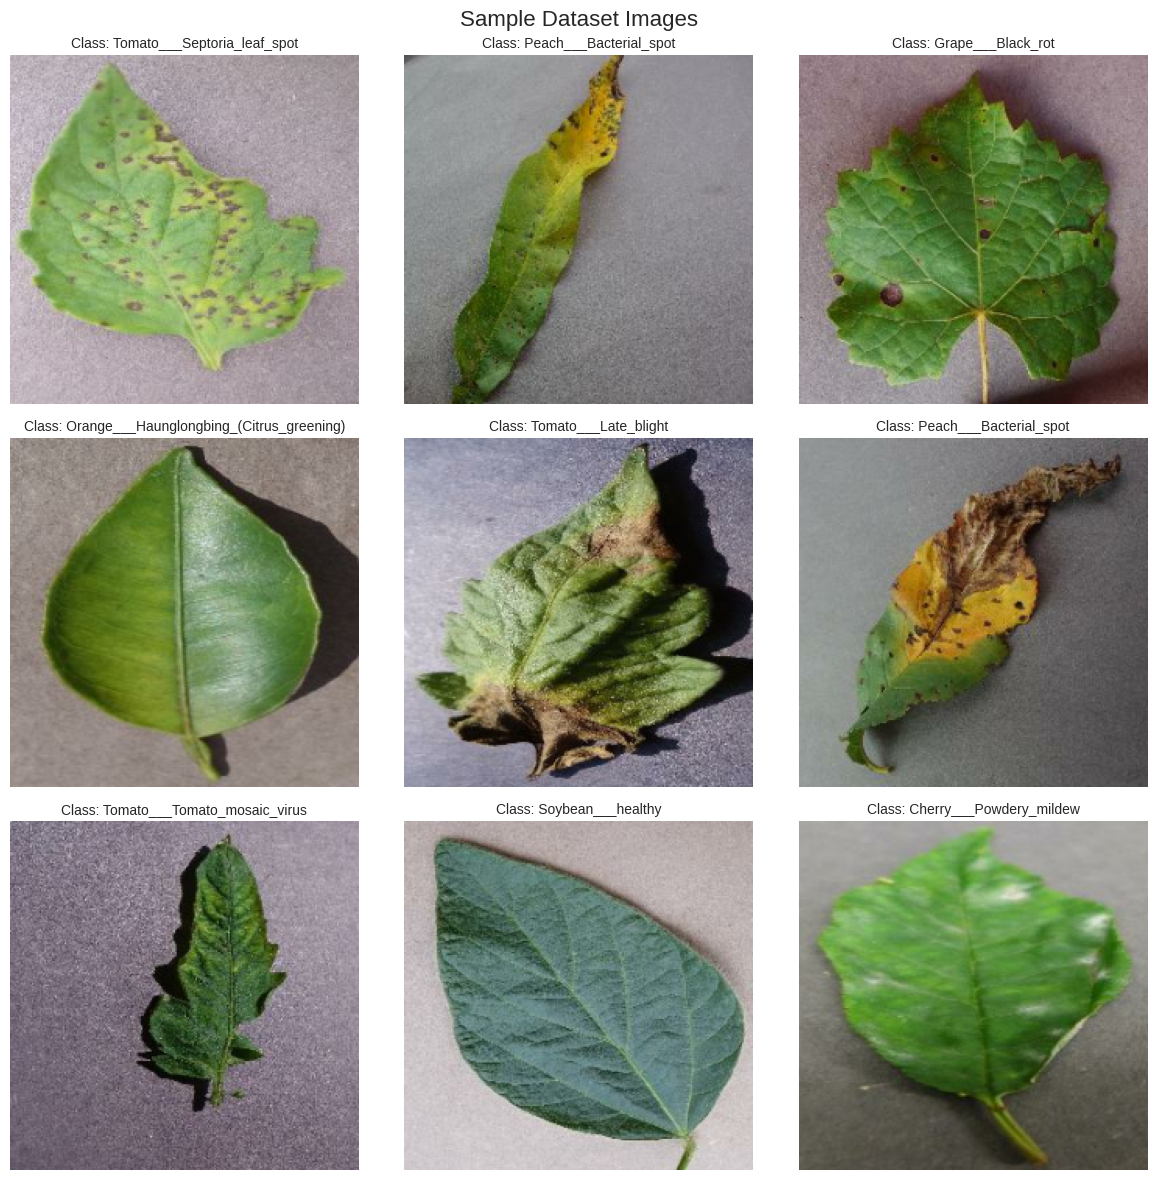

In [5]:
def plot_sample_images(dataset, class_names, num_images=9):
    """
    Visualisasi sample gambar dari dataset
    """
    plt.figure(figsize=(12, 12))

    # Ambil satu batch dari dataset
    for images, labels in dataset.take(1):
        for i in range(min(num_images, len(images))):
            plt.subplot(3, 3, i + 1)
            plt.imshow(images[i])
            plt.title(f"Class: {class_names[labels[i]]}", fontsize=10)
            plt.axis('off')

    plt.suptitle('Sample Dataset Images', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualisasi sample images
plot_sample_images(val_dataset, class_names)

## 7. Pembuatan Model dengan Transfer Learning

In [6]:
def create_model(num_classes, img_size=224):
    """
    Membuat model menggunakan transfer learning dengan MobileNetV2
    MobileNetV2 dipilih karena ringan namun akurat, cocok untuk deployment
    """
    with strategy.scope():
        # Load pretrained MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=(img_size, img_size, 3),
            include_top=False,
            weights='imagenet'
        )

        # Freeze base model layers
        base_model.trainable = False

        # Tambahkan custom layers
        model = tf.keras.Sequential([
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(num_classes, activation='softmax', dtype='float32')
        ])

        return model

# Buat model
model = create_model(len(class_names))

# Compile model
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# Print model summary
print("Model Architecture:")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Training Model

In [7]:
# Callback untuk monitoring training
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False
    )
]

print("Memulai training model...")
print("Estimasi waktu: 15-20 menit dengan dataset yang lebih besar")

# Training model
EPOCHS = 20

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

print("✅ Training selesai!")

Memulai training model...
Estimasi waktu: 15-20 menit dengan dataset yang lebih besar


W0000 00:00:1749018506.984090      35 auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


Epoch 1/20


I0000 00:00:1749018518.817935      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.3323 - loss: 2.6457

W0000 00:00:1749018528.888154      35 auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 188ms/step - accuracy: 0.3344 - loss: 2.6366 - val_accuracy: 0.7482 - val_loss: 0.9682 - learning_rate: 0.0010
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.7207 - loss: 0.9644 - val_accuracy: 0.8228 - val_loss: 0.6377 - learning_rate: 0.0010
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.8028 - loss: 0.6629 - val_accuracy: 0.8360 - val_loss: 0.5198 - learning_rate: 0.0010
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - accuracy: 0.8404 - loss: 0.5175 - val_accuracy: 0.8395 - val_loss: 0.4838 - learning_rate: 0.0010
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - accuracy: 0.8735 - loss: 0.4183 - val_accuracy: 0.8693 - val_loss: 0.4142 - learning_rate: 0.0010
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.8808 - loss: 0.3761 - val_accuracy: 0.8640 - val_loss: 0.3986 - learning_rate: 0.0010
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 125ms/step - accuracy: 0.8903 - loss: 0.3446 - val_

## 9. Evaluasi Model

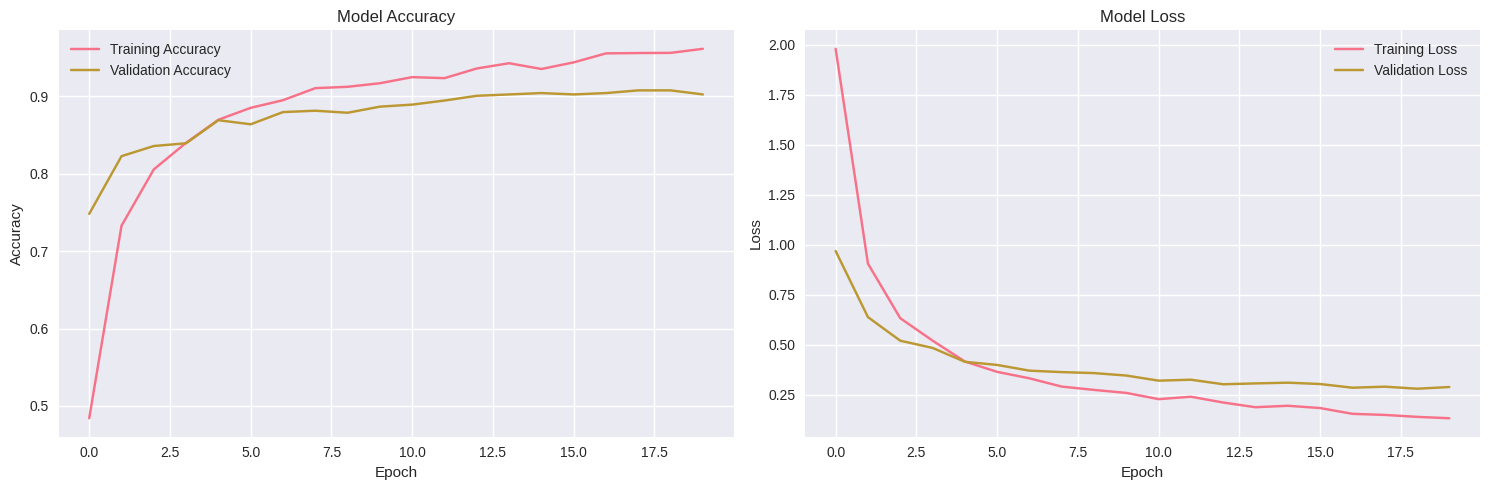

📊 Evaluasi Model pada Validation Set:


W0000 00:00:1749018739.010905      35 auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


Validation Loss: 0.2898
Validation Accuracy: 0.9079


In [8]:
def plot_training_history(history):
    """
    Plot training history
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

# Evaluasi model pada validation set
print("📊 Evaluasi Model pada Validation Set:")
val_loss, val_accuracy = model.evaluate(val_dataset, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

## 10. Fine-tuning Model

In [9]:
# Unfreeze beberapa layer terakhir untuk fine-tuning
print("Fine-tuning model...")

with strategy.scope():
    # Unfreeze top layers dari base model
    base_model = model.layers[0]
    base_model.trainable = True

    # Fine-tune dari layer ke-100 dan seterusnya
    fine_tune_at = 100

    # Freeze semua layer hingga fine_tune_at
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Recompile dengan learning rate yang lebih kecil
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001/10),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("Model siap untuk fine-tuning")

# Fine-tuning dengan epochs yang lebih sedikit
fine_tune_epochs = 8
total_epochs = EPOCHS + fine_tune_epochs

history_fine = model.fit(
    train_dataset,
    epochs=total_epochs,
    initial_epoch=len(history.history['loss']),
    validation_data=val_dataset,
    callbacks=callbacks,
    verbose=1
)

print("Fine-tuning selesai!")

Fine-tuning model...
Model siap untuk fine-tuning


W0000 00:00:1749018740.994293      35 auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


Epoch 21/28
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4978 - loss: 2.2789

W0000 00:00:1749018766.233107      35 auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


72/72 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.4986 - loss: 2.2737 - val_accuracy: 0.8895 - val_loss: 0.3761 - learning_rate: 1.0000e-05
Epoch 22/28
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.7152 - loss: 1.0261 - val_accuracy: 0.8789 - val_loss: 0.4340 - learning_rate: 1.0000e-05
Epoch 23/28
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.8066 - loss: 0.6137 - val_accuracy: 0.8754 - val_loss: 0.4442 - learning_rate: 1.0000e-05
Epoch 24/28
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - accuracy: 0.8514 - loss: 0.4431 - val_accuracy: 0.8737 - val_loss: 0.4479 - learning_rate: 1.0000e-05
Epoch 25/28
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.8621 - loss: 0.4133 - val_accuracy: 0.8719 - val_loss: 0.4298 - learning_rate: 5.0000e-06
Epoch 26/28
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.8776 - loss: 0.3580 - val_accuracy: 0.8825 - val_loss: 0.4128 - learning_rate: 5.0000e-06
Fine-tuning selesai!


## 11. Simpan Model untuk TensorFlow.js

In [14]:
import os
import json
import tensorflowjs as tfjs

# Buat direktori untuk menyimpan model
os.makedirs('models/saved_model', exist_ok=True)
os.makedirs('models/tfjs_model', exist_ok=True)

# Simpan model dalam format SavedModel (untuk TFJS)
model_path = 'models/saved_model'
model.export(model_path)  # Gunakan export untuk Keras 3.x+
print(f"Model disimpan di: {model_path}")

# Konversi ke TensorFlow.js format
print("Mengkonversi model ke format TensorFlow.js...")
tfjs_model_path = 'models/tfjs_model'
tfjs.converters.convert_tf_saved_model(model_path, tfjs_model_path)
print(f"Model TensorFlow.js disimpan di: {tfjs_model_path}")

# Simpan class names
class_names_path = 'models/class_names.json'
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"Class names disimpan di: {class_names_path}")


Saved artifact at 'models/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float16, name='keras_tensor_155')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  132880730505296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132882859247760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132876868115664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132876868124496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132880730508368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132876868116048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132876308218512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132876308217936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132882859249296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132880730508176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1328763

I0000 00:00:1749019119.132213      35 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1749019119.132391      35 single_machine.cc:361] Starting new session
I0000 00:00:1749019119.134678      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749019119.134902      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


weight StatefulPartitionedCall/sequential_1/mobilenetv2_1.00_224_1/Conv1_1/convolution/Cast with shape (3, 3, 3, 32) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/sequential_1/mobilenetv2_1.00_224_1/expanded_conv_depthwise_1/depthwise/Cast with shape (3, 3, 32, 1) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/sequential_1/mobilenetv2_1.00_224_1/expanded_conv_project_1/convolution/Cast with shape (1, 1, 32, 16) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/sequential_1/mobilenetv2_1.00_224_1/block_1_expand_1/convolution/Cast with shape (1, 1, 16, 96) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/sequential_1/mobilenetv2_1.00_224_1/block_1_depthwise_1/depthwise/Cast with shape (3, 3, 96, 1) and dtype float16 was auto converted to the type float32
weight StatefulPartitionedCall/sequential_1/mobilenetv2_1.00_224_1/block_1_pr

## 12. Test Inferensi Model

🔍 Testing model inference...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


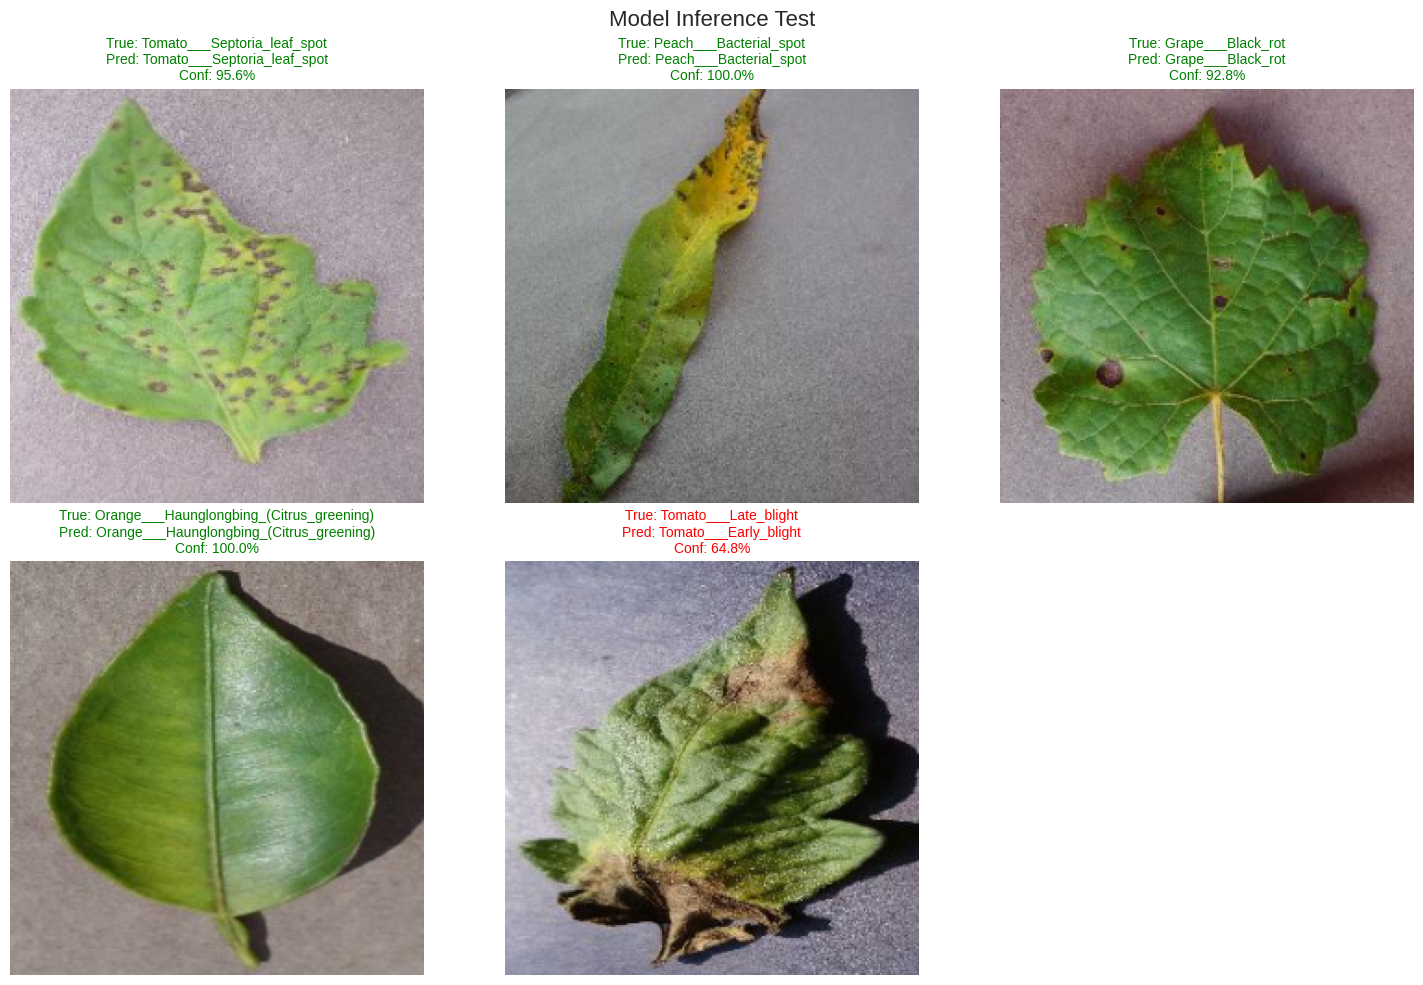

In [15]:
def test_model_inference(model, test_dataset, class_names, num_predictions=5):
    """
    Test inferensi model dengan beberapa sampel
    """
    print("🔍 Testing model inference...")

    # Ambil beberapa sampel untuk prediksi
    for images, true_labels in test_dataset.take(1):
        predictions = model.predict(images[:num_predictions])
        predicted_labels = np.argmax(predictions, axis=1)

        plt.figure(figsize=(15, 10))
        for i in range(num_predictions):
            plt.subplot(2, 3, i + 1)
            plt.imshow(images[i])

            true_class = class_names[true_labels[i]]
            pred_class = class_names[predicted_labels[i]]
            confidence = np.max(predictions[i]) * 100

            color = 'green' if true_labels[i] == predicted_labels[i] else 'red'
            plt.title(f'True: {true_class}\nPred: {pred_class}\nConf: {confidence:.1f}%',
                     color=color, fontsize=10)
            plt.axis('off')

        plt.suptitle('Model Inference Test', fontsize=16)
        plt.tight_layout()
        plt.show()
        break

# Test inferensi
test_model_inference(model, val_dataset, class_names)

## 13. Evaluasi Detail Model

Evaluasi detail model...

 Classification Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.93      0.87      0.90        15
                            Apple___Black_rot       1.00      0.80      0.89        15
                     Apple___Cedar_apple_rust       1.00      0.43      0.60         7
                              Apple___healthy       0.94      0.87      0.90        38
                          Blueberry___healthy       1.00      1.00      1.00        34
                             Cherry___healthy       1.00      0.89      0.94        19
                      Cherry___Powdery_mildew       1.00      0.92      0.96        24
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.57      0.67      0.62         6
                           Corn___Common_rust       1.00      1.00      1.00        22
                               Corn___healthy       1.00      1.00      1.00   

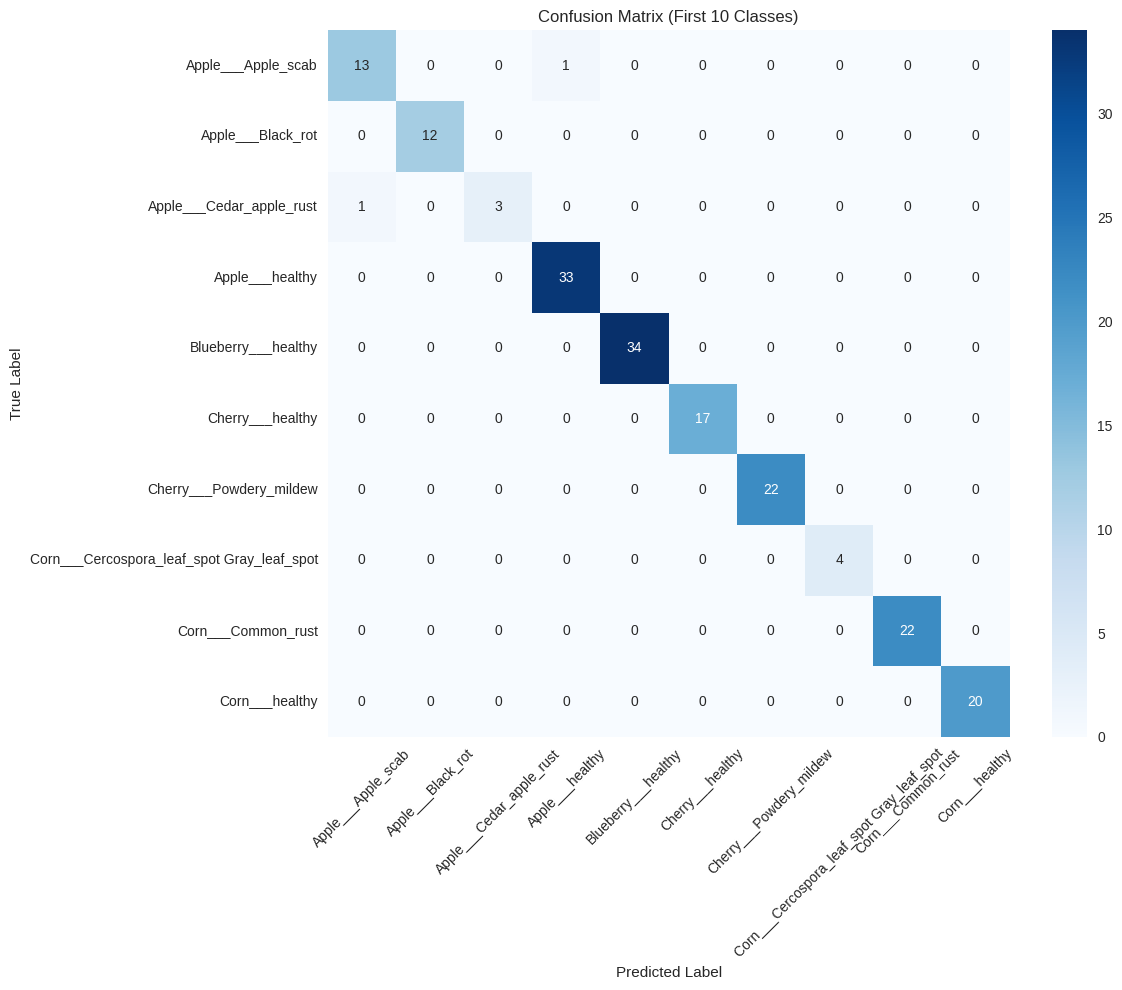

In [16]:
def detailed_evaluation(model, test_dataset, class_names):
    """
    Evaluasi detail dengan confusion matrix dan classification report
    """
    print("Evaluasi detail model...")

    # Collect all predictions and true labels
    all_predictions = []
    all_true_labels = []

    for images, labels in test_dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        all_predictions.extend(predicted_labels)
        all_true_labels.extend(labels.numpy())

    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_true_labels = np.array(all_true_labels)

    # Classification report
    print("\n Classification Report:")
    print(classification_report(all_true_labels, all_predictions,
                              target_names=class_names, zero_division=0))

    # Confusion matrix (simplified - show only first 10 classes)
    cm = confusion_matrix(all_true_labels, all_predictions)

    plt.figure(figsize=(12, 10))
    # Show only subset of confusion matrix for readability
    subset_size = min(10, len(class_names))
    cm_subset = cm[:subset_size, :subset_size]
    class_names_subset = class_names[:subset_size]

    sns.heatmap(cm_subset, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_subset,
                yticklabels=class_names_subset)
    plt.title('Confusion Matrix (First 10 Classes)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return all_predictions, all_true_labels

# Evaluasi detail
predictions, true_labels = detailed_evaluation(model, val_dataset, class_names)

## 14. Informasi Model untuk Backend Integration

In [17]:
# Evaluasi final
final_val_loss, final_val_accuracy = model.evaluate(val_dataset, verbose=0)

# Informasi model untuk dokumentasi
model_info = {
    'model_name': 'AgriScan Plant Disease Classifier',
    'architecture': 'MobileNetV2 with Transfer Learning',
    'input_shape': [224, 224, 3],
    'num_classes': len(class_names),
    'model_size_mb': round(os.path.getsize('models/saved_model/saved_model.pb') / (1024*1024), 2),
    'training_accuracy': round(float(history.history['accuracy'][-1]), 4),
    'validation_accuracy': round(float(final_val_accuracy), 4),
    'total_epochs': len(history.history['accuracy']) + len(history_fine.history['accuracy']),
    'batch_size': BATCH_SIZE,
    'image_size': IMG_SIZE,
    'class_names': class_names
}

# Simpan informasi model
with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print("Informasi Model:")
for key, value in model_info.items():
    if key != 'class_names':
        print(f"  {key}: {value}")

print(f"\n Semua file model berhasil disimpan!")
print(f" Struktur file yang dihasilkan:")
print(f"  - models/saved_model/          # TensorFlow SavedModel")
print(f"  - models/tfjs_model/           # TensorFlow.js Model")
print(f"  - models/class_names.json      # Nama kelas untuk inferensi")
print(f"  - models/model_info.json       # Informasi detail model")
print(f"  - best_model.h5                # Best model checkpoint")

W0000 00:00:1749019171.140869      35 auto_shard.cc:553] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.


Informasi Model:
  model_name: AgriScan Plant Disease Classifier
  architecture: MobileNetV2 with Transfer Learning
  input_shape: [224, 224, 3]
  num_classes: 38
  model_size_mb: 1.62
  training_accuracy: 0.9616
  validation_accuracy: 0.8895
  total_epochs: 26
  batch_size: 64
  image_size: 224

 Semua file model berhasil disimpan!
 Struktur file yang dihasilkan:
  - models/saved_model/          # TensorFlow SavedModel
  - models/tfjs_model/           # TensorFlow.js Model
  - models/class_names.json      # Nama kelas untuk inferensi
  - models/model_info.json       # Informasi detail model
  - best_model.h5                # Best model checkpoint


In [18]:
import shutil

# Tentukan jalur folder yang ingin di-zip
folder_path = "/kaggle/working/models"
zip_path = "/kaggle/working/models.zip"

# Buat file ZIP dari folder
shutil.make_archive(zip_path.replace(".zip", ""), 'zip', folder_path)

print(f"Folder '{folder_path}' telah berhasil di-zip menjadi '{zip_path}'")


Folder '/kaggle/working/models' telah berhasil di-zip menjadi '/kaggle/working/models.zip'
